In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
df= pd.read_csv("NACA2412_Re1M.txt", sep=r"\s+", skiprows=11, header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11
0,-4.0000,-0.1968,0.00770,0.00224,-0.0554,0.8835,0.1139,-1.6376,0.0,0.0,0.0,-0.0414
1,-3.5000,-0.1421,0.00736,0.00197,-0.0550,0.8621,0.1482,-1.4120,0.0,0.0,0.0,-0.1485
2,-0.0547,0.8374,0.18710,-1.19710,0.0000,0.0000,0.0000,-0.3906,NaN,NaN,NaN,NaN
3,-2.5000,-0.0326,0.00679,0.00156,-0.0543,0.8112,0.2376,-0.9999,0.0,0.0,0.0,-1.4485
4,-2.0000,0.0222,0.00656,0.00142,-0.0540,0.7818,0.2940,-0.8325,0.0,0.0,0.0,2.7197


In [7]:
df.columns = [
    "Alpha", "CL", "CD", "CDp", "Cm",
    "Top_Xtr", "Bot_Xtr", "Cpmin", "Chinge", "XCp", "Extra1", "Extra2"
]
df.head()

,Alpha,CL,CD,CDp,Cm,Top_Xtr,Bot_Xtr,Cpmin,Chinge,XCp,Extra1,Extra2
0,-4.0000,-0.1968,0.00770,0.00224,-0.0554,0.8835,0.1139,-1.6376,0.0,0.0,0.0,-0.0414
1,-3.5000,-0.1421,0.00736,0.00197,-0.0550,0.8621,0.1482,-1.4120,0.0,0.0,0.0,-0.1485
2,-0.0547,0.8374,0.18710,-1.19710,0.0000,0.0000,0.0000,-0.3906,NaN,NaN,NaN,NaN
3,-2.5000,-0.0326,0.00679,0.00156,-0.0543,0.8112,0.2376,-0.9999,0.0,0.0,0.0,-1.4485
4,-2.0000,0.0222,0.00656,0.00142,-0.0540,0.7818,0.2940,-0.8325,0.0,0.0,0.0,2.7197


In [8]:
df["L_D"] = df["CL"] / df["CD"]

df[["Alpha", "CL", "CD", "L_D"]].head()

,Alpha,CL,CD,L_D
0,-4.0000,-0.1968,0.00770,-25.558442
1,-3.5000,-0.1421,0.00736,-19.307065
2,-0.0547,0.8374,0.18710,4.475681
3,-2.5000,-0.0326,0.00679,-4.801178
4,-2.0000,0.0222,0.00656,3.384146


In [9]:
max_ld = df["L_D"].max()
alpha_opt = df.loc[df["L_D"].idxmax(), "Alpha"]

print("Max L/D =", max_ld)
print("Optimal alpha =", alpha_opt, "deg")

Max L/D = 105.40055248618785
Optimal alpha = 4.5 deg


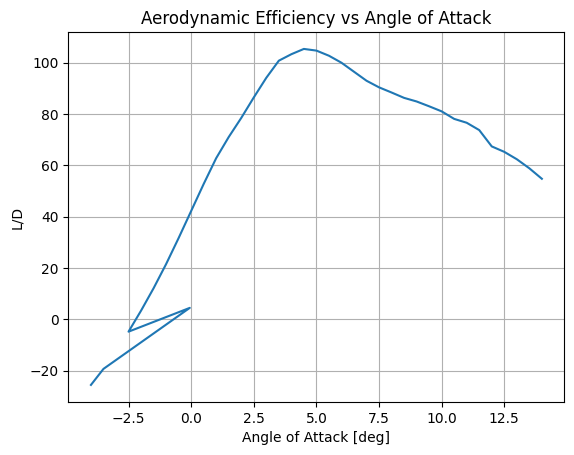

In [10]:
plt.plot(df["Alpha"], df["L_D"])
plt.xlabel("Angle of Attack [deg]")
plt.ylabel("L/D")
plt.title("Aerodynamic Efficiency vs Angle of Attack")
plt.grid()
plt.show()

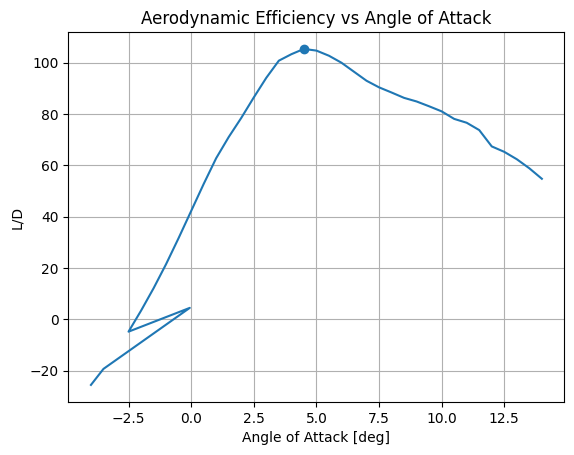

In [11]:
plt.plot(df["Alpha"], df["L_D"])
plt.scatter(alpha_opt, max_ld)

plt.xlabel("Angle of Attack [deg]")
plt.ylabel("L/D")
plt.title("Aerodynamic Efficiency vs Angle of Attack")
plt.grid()

plt.show()

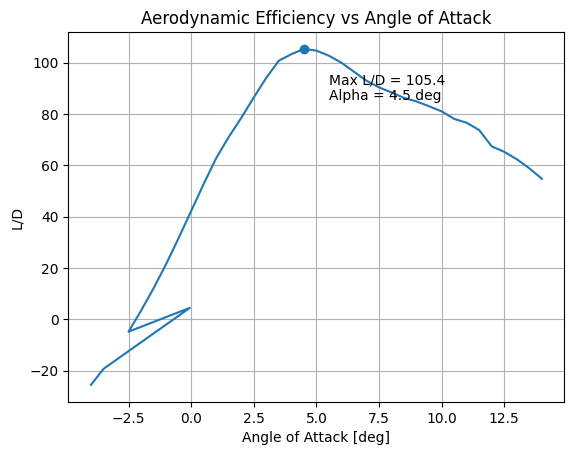

In [12]:
plt.plot(df["Alpha"], df["L_D"])
plt.scatter(alpha_opt, max_ld)

plt.annotate(
    f"Max L/D = {max_ld:.1f}\nAlpha = {alpha_opt:.1f} deg",
    (alpha_opt, max_ld),
    xytext=(alpha_opt + 1, max_ld - 20)
)

plt.xlabel("Angle of Attack [deg]")
plt.ylabel("L/D")
plt.title("Aerodynamic Efficiency vs Angle of Attack")
plt.grid()
plt.show()

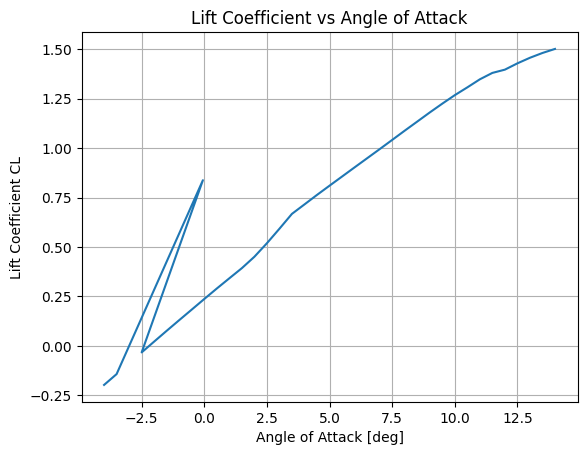

In [13]:
plt.plot(df["Alpha"], df["CL"])

plt.xlabel("Angle of Attack [deg]")
plt.ylabel("Lift Coefficient CL")
plt.title("Lift Coefficient vs Angle of Attack")
plt.grid()

plt.show()

In [14]:
max_cl = df["CL"].max()
alpha_clmax = df.loc[df["CL"].idxmax(), "Alpha"]

print("Max CL =", max_cl)
print("Alpha at max CL =", alpha_clmax, "deg")

Max CL = 1.5006
Alpha at max CL = 14.0 deg


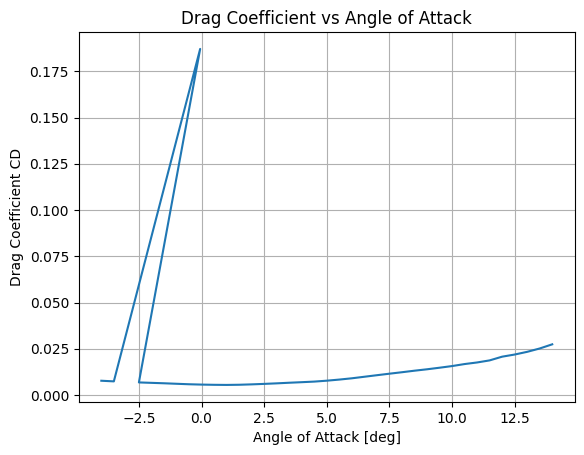

In [15]:
plt.plot(df["Alpha"], df["CD"])

plt.xlabel("Angle of Attack [deg]")
plt.ylabel("Drag Coefficient CD")
plt.title("Drag Coefficient vs Angle of Attack")
plt.grid()

plt.show()

In [16]:
rho = 1.225
V = 40
S = 10

df["Lift_N"] = 0.5 * rho * V**2 * S * df["CL"]
df["Drag_N"] = 0.5 * rho * V**2 * S * df["CD"]

df[["Alpha", "Lift_N", "Drag_N"]].head()

,Alpha,Lift_N,Drag_N
0,-4.0000,-1928.64,75.460
1,-3.5000,-1392.58,72.128
2,-0.0547,8206.52,1833.580
3,-2.5000,-319.48,66.542
4,-2.0000,217.56,64.288


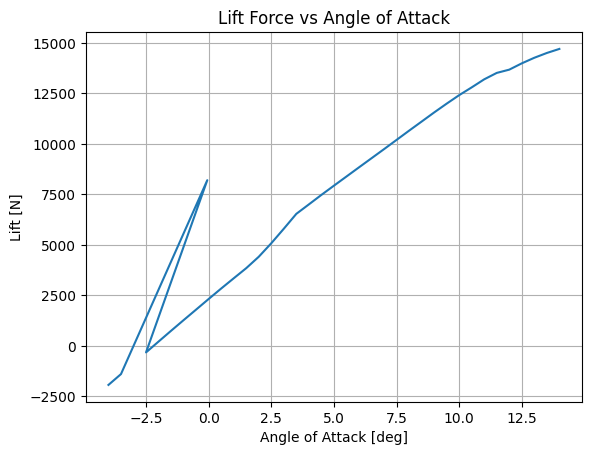

In [17]:
plt.plot(df["Alpha"], df["Lift_N"])

plt.xlabel("Angle of Attack [deg]")
plt.ylabel("Lift [N]")
plt.title("Lift Force vs Angle of Attack")
plt.grid()

plt.show()

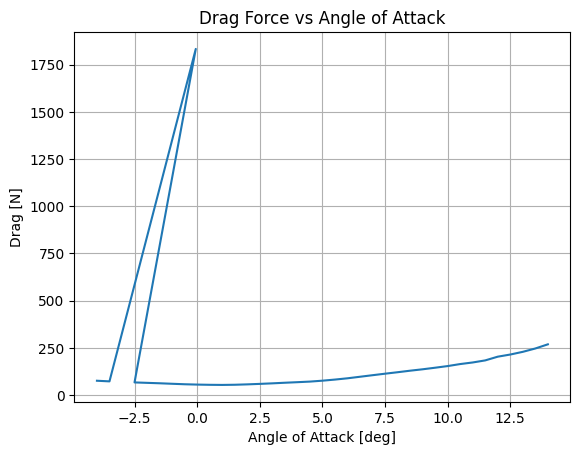

In [18]:
plt.plot(df["Alpha"], df["Drag_N"])

plt.xlabel("Angle of Attack [deg]")
plt.ylabel("Drag [N]")
plt.title("Drag Force vs Angle of Attack")
plt.grid()

plt.show()

In [19]:
df["Drag_Power_W"] = df["Drag_N"] * V

df[["Alpha", "Drag_N", "Drag_Power_W"]].head()

,Alpha,Drag_N,Drag_Power_W
0,-4.0000,75.460,3018.40
1,-3.5000,72.128,2885.12
2,-0.0547,1833.580,73343.20
3,-2.5000,66.542,2661.68
4,-2.0000,64.288,2571.52


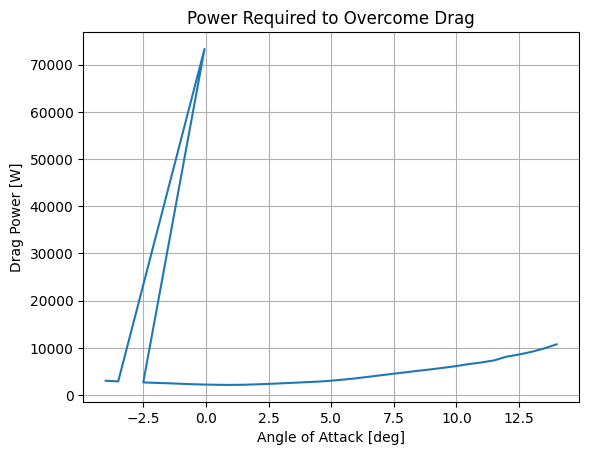

In [20]:
plt.plot(df["Alpha"], df["Drag_Power_W"])

plt.xlabel("Angle of Attack [deg]")
plt.ylabel("Drag Power [W]")
plt.title("Power Required to Overcome Drag")
plt.grid()

plt.show()

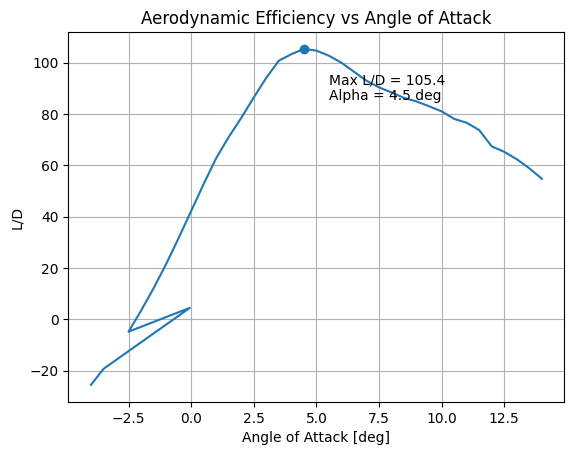

In [22]:
plt.plot(df["Alpha"], df["L_D"])
plt.scatter(alpha_opt, max_ld)

plt.annotate(
    f"Max L/D = {max_ld:.1f}\nAlpha = {alpha_opt:.1f} deg",
    (alpha_opt, max_ld),
    xytext=(alpha_opt + 1, max_ld - 20)
)

plt.xlabel("Angle of Attack [deg]")
plt.ylabel("L/D")
plt.title("Aerodynamic Efficiency vs Angle of Attack")
plt.grid()

plt.savefig("LD_vs_Alpha.png", dpi=300, bbox_inches="tight")
plt.show()

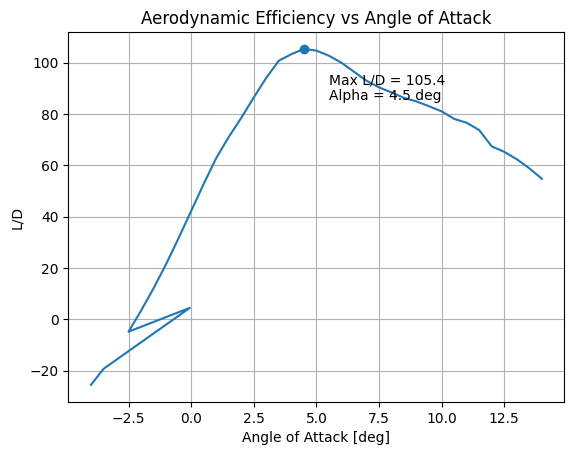

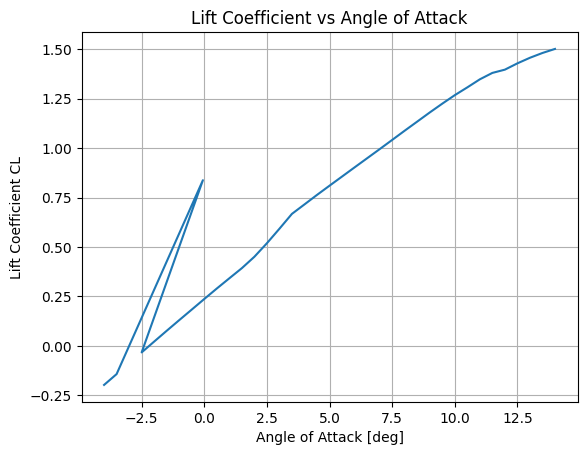

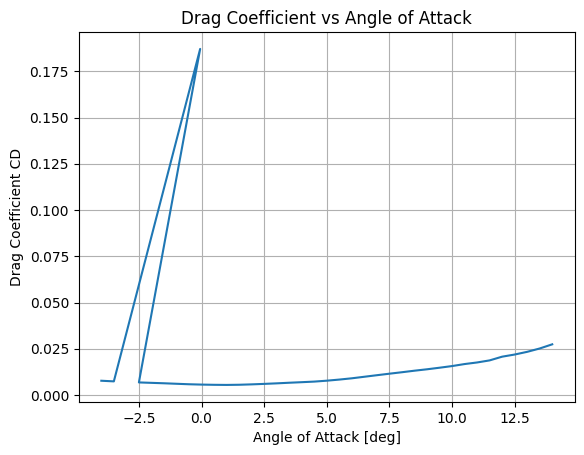

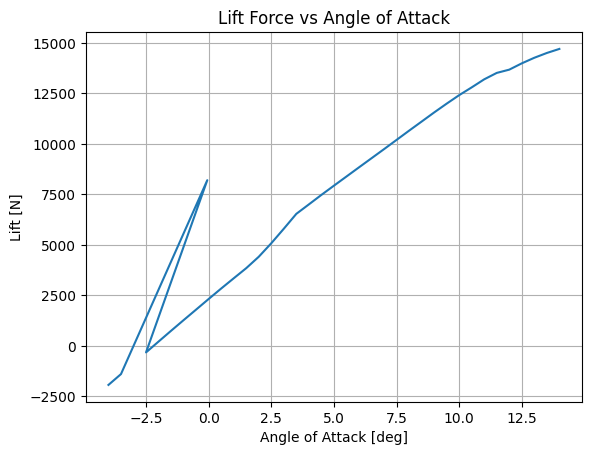

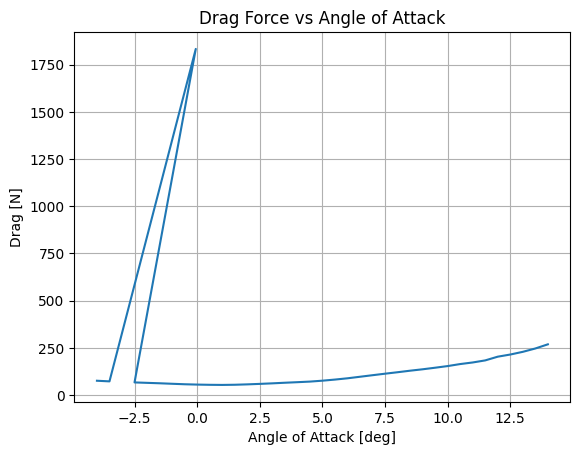

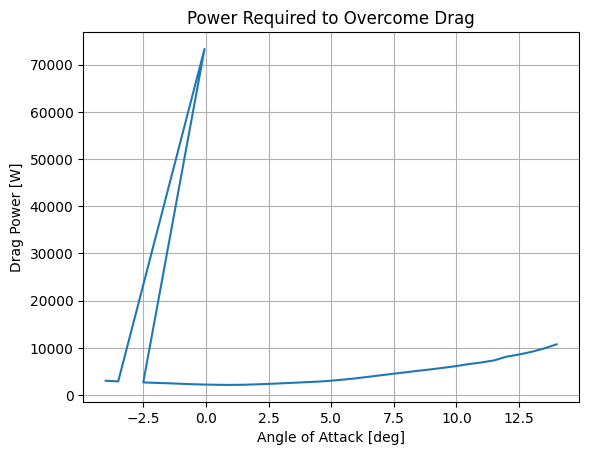

In [23]:
# 1) Aerodynamic Efficiency - L/D vs Alpha
plt.figure()
plt.plot(df["Alpha"], df["L_D"])
plt.scatter(alpha_opt, max_ld)

plt.annotate(
    f"Max L/D = {max_ld:.1f}\nAlpha = {alpha_opt:.1f} deg",
    (alpha_opt, max_ld),
    xytext=(alpha_opt + 1, max_ld - 20)
)

plt.xlabel("Angle of Attack [deg]")
plt.ylabel("L/D")
plt.title("Aerodynamic Efficiency vs Angle of Attack")
plt.grid()

plt.savefig("LD_vs_Alpha.png", dpi=300, bbox_inches="tight")
plt.show()


# 2) Lift Coefficient - CL vs Alpha
plt.figure()
plt.plot(df["Alpha"], df["CL"])

plt.xlabel("Angle of Attack [deg]")
plt.ylabel("Lift Coefficient CL")
plt.title("Lift Coefficient vs Angle of Attack")
plt.grid()

plt.savefig("CL_vs_Alpha.png", dpi=300, bbox_inches="tight")
plt.show()


# 3) Drag Coefficient - CD vs Alpha
plt.figure()
plt.plot(df["Alpha"], df["CD"])

plt.xlabel("Angle of Attack [deg]")
plt.ylabel("Drag Coefficient CD")
plt.title("Drag Coefficient vs Angle of Attack")
plt.grid()

plt.savefig("CD_vs_Alpha.png", dpi=300, bbox_inches="tight")
plt.show()


# 4) Lift Force vs Alpha
plt.figure()
plt.plot(df["Alpha"], df["Lift_N"])

plt.xlabel("Angle of Attack [deg]")
plt.ylabel("Lift [N]")
plt.title("Lift Force vs Angle of Attack")
plt.grid()

plt.savefig("Lift_vs_Alpha.png", dpi=300, bbox_inches="tight")
plt.show()


# 5) Drag Force vs Alpha
plt.figure()
plt.plot(df["Alpha"], df["Drag_N"])

plt.xlabel("Angle of Attack [deg]")
plt.ylabel("Drag [N]")
plt.title("Drag Force vs Angle of Attack")
plt.grid()

plt.savefig("Drag_vs_Alpha.png", dpi=300, bbox_inches="tight")
plt.show()


# 6) Drag Power vs Alpha
plt.figure()
plt.plot(df["Alpha"], df["Drag_Power_W"])

plt.xlabel("Angle of Attack [deg]")
plt.ylabel("Drag Power [W]")
plt.title("Power Required to Overcome Drag")
plt.grid()

plt.savefig("DragPower_vs_Alpha.png", dpi=300, bbox_inches="tight")
plt.show()

In [25]:
df500 = pd.read_csv("NACA 2412_Re500k.txt", sep=r"\s+", skiprows=11, header=None)
df1M = pd.read_csv("NACA2412_Re1M.txt", sep=r"\s+", skiprows=11, header=None)
df3M = pd.read_csv("NACA 2412_Re3M.txt", sep=r"\s+", skiprows=11, header=None)

In [27]:
columns = [
    "Alpha", "CL", "CD", "CDp", "Cm",
    "Top_Xtr", "Bot_Xtr", "Cpmin", "Chinge", "XCp", "Extra1", "Extra2"
]

df500.columns = columns
df1M.columns = columns
df3M.columns = columns
df500.head()

,Alpha,CL,CD,CDp,Cm,Top_Xtr,Bot_Xtr,Cpmin,Chinge,XCp,Extra1,Extra2
0,-4.0,-0.1896,0.00947,0.00343,-0.0586,0.9316,0.1512,-1.6160,0.0,0.0,0.0,-0.0697
1,-3.5,-0.1345,0.00896,0.00304,-0.0583,0.9158,0.1967,-1.3922,0.0,0.0,0.0,-0.1955
2,-3.0,-0.0806,0.00845,0.00271,-0.0576,0.8965,0.2536,-1.1809,0.0,0.0,0.0,-0.4808
3,-2.5,-0.0271,0.00801,0.00244,-0.0569,0.8750,0.3206,-0.9900,0.0,0.0,0.0,-1.8904
4,-2.0,0.0258,0.00756,0.00221,-0.0560,0.8500,0.4043,-0.8263,0.0,0.0,0.0,2.4564


In [28]:
df500["L_D"] = df500["CL"] / df500["CD"]
df1M["L_D"] = df1M["CL"] / df1M["CD"]
df3M["L_D"] = df3M["CL"] / df3M["CD"]
print("Re 500k:", df500["L_D"].max())
print("Re 1M:", df1M["L_D"].max())
print("Re 3M:", df3M["L_D"].max())

Re 500k: 89.59957850368808
Re 1M: 105.40055248618785
Re 3M: 119.48853615520282


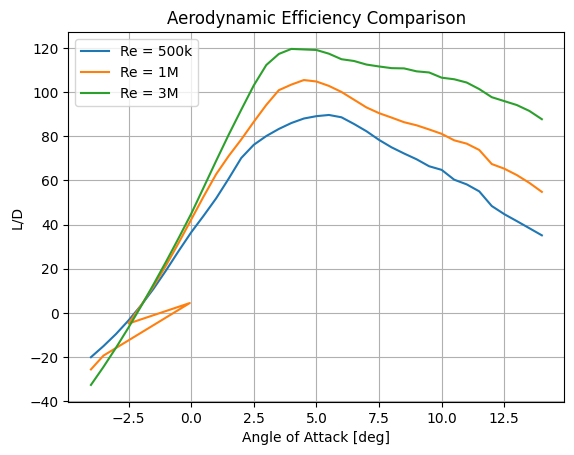

In [29]:
plt.figure()

plt.plot(df500["Alpha"], df500["L_D"], label="Re = 500k")
plt.plot(df1M["Alpha"], df1M["L_D"], label="Re = 1M")
plt.plot(df3M["Alpha"], df3M["L_D"], label="Re = 3M")

plt.xlabel("Angle of Attack [deg]")
plt.ylabel("L/D")
plt.title("Aerodynamic Efficiency Comparison")
plt.grid()
plt.legend()

plt.show()

In [30]:
summary = pd.DataFrame({
    "Reynolds": [500000, 1000000, 3000000],
    "Max_L_D": [
        df500["L_D"].max(),
        df1M["L_D"].max(),
        df3M["L_D"].max()
    ],
    "Alpha_opt_deg": [
        df500.loc[df500["L_D"].idxmax(), "Alpha"],
        df1M.loc[df1M["L_D"].idxmax(), "Alpha"],
        df3M.loc[df3M["L_D"].idxmax(), "Alpha"]
    ]
})

summary

,Reynolds,Max_L_D,Alpha_opt_deg
0,500000,89.599579,5.5
1,1000000,105.400552,4.5
2,3000000,119.488536,4.0


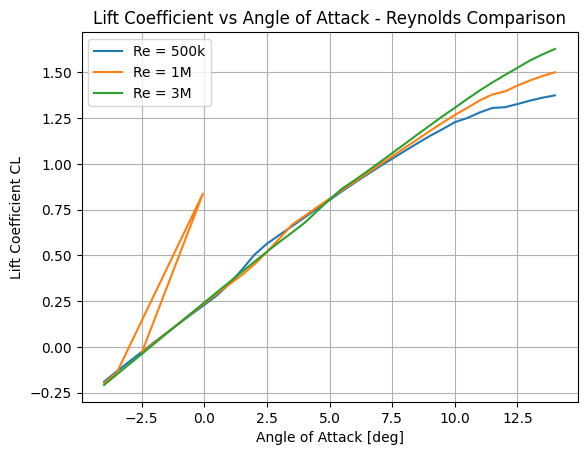

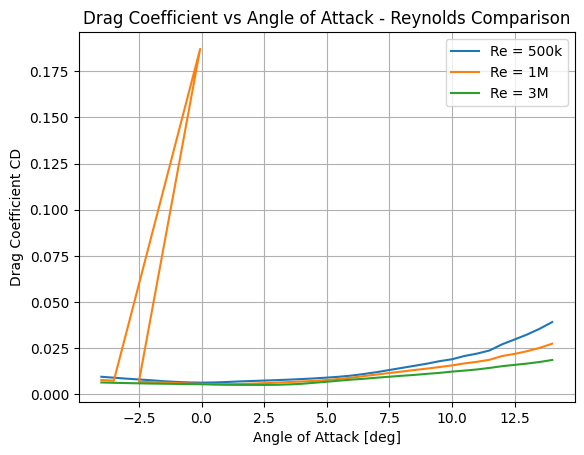

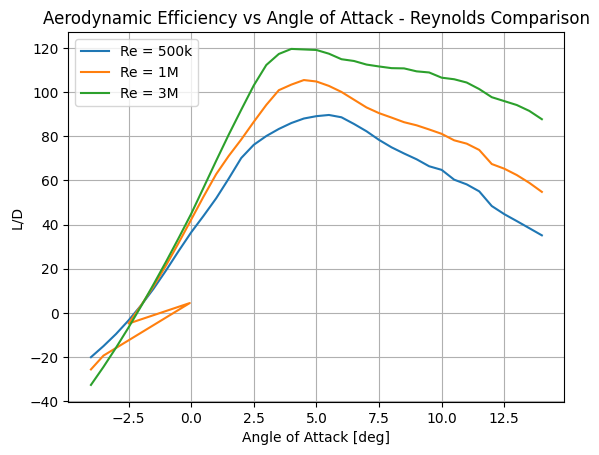

In [31]:
# 1) CL vs Alpha - confronto Reynolds
plt.figure()

plt.plot(df500["Alpha"], df500["CL"], label="Re = 500k")
plt.plot(df1M["Alpha"], df1M["CL"], label="Re = 1M")
plt.plot(df3M["Alpha"], df3M["CL"], label="Re = 3M")

plt.xlabel("Angle of Attack [deg]")
plt.ylabel("Lift Coefficient CL")
plt.title("Lift Coefficient vs Angle of Attack - Reynolds Comparison")
plt.grid()
plt.legend()

plt.savefig("CL_Reynolds_Comparison.png", dpi=300, bbox_inches="tight")
plt.show()


# 2) CD vs Alpha - confronto Reynolds
plt.figure()

plt.plot(df500["Alpha"], df500["CD"], label="Re = 500k")
plt.plot(df1M["Alpha"], df1M["CD"], label="Re = 1M")
plt.plot(df3M["Alpha"], df3M["CD"], label="Re = 3M")

plt.xlabel("Angle of Attack [deg]")
plt.ylabel("Drag Coefficient CD")
plt.title("Drag Coefficient vs Angle of Attack - Reynolds Comparison")
plt.grid()
plt.legend()

plt.savefig("CD_Reynolds_Comparison.png", dpi=300, bbox_inches="tight")
plt.show()


# 3) L/D vs Alpha - confronto Reynolds
plt.figure()

plt.plot(df500["Alpha"], df500["L_D"], label="Re = 500k")
plt.plot(df1M["Alpha"], df1M["L_D"], label="Re = 1M")
plt.plot(df3M["Alpha"], df3M["L_D"], label="Re = 3M")

plt.xlabel("Angle of Attack [deg]")
plt.ylabel("L/D")
plt.title("Aerodynamic Efficiency vs Angle of Attack - Reynolds Comparison")
plt.grid()
plt.legend()

plt.savefig("LD_Reynolds_Comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [33]:
df500["Reynolds"] = 500000
df1M["Reynolds"] = 1000000
df3M["Reynolds"] = 3000000

df_all = pd.concat([df500, df1M, df3M], ignore_index=True)

df_all.to_csv("NACA2412_All_Reynolds.csv", index=False)